# ASI Problem Set 3 Code
---
## Housekeeping

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import xarray as xr
from pathlib import Path
import seaborn as sns

In [2]:
#Given Values
SST = 26 #deg C
T_deep = 23 #deg C
z_u = 40 #m
z_l = 60 #m

S_SSS = 34 #PSU
hf = -15 #W/m^2
u = 6 #m/s
v = 0 #m/s
tau = 0.1125 #N/m^2

### T & S Profiles:

$$
T(z) = SST - \frac{SST - T_{\rm deep}}{2} 
\cdot 
\frac{\tanh\left(\frac{z - z_{u\text{-thermocline}}}{6}\right)}
{\tanh\left(\frac{z_{l\text{-thermocline}} - z_{u\text{-thermocline}}}{6}\right)} - 
\frac{SST - T_{deep}}{2}
$$
Note that in this notation, depths are positive

In [3]:
def get_t_prof(z, SST=SST, T_deep=T_deep, z_u=z_u, z_l=z_l):
    """
    Function that generates temperature profiles
    
    Parameters:
    z : depth
    SST : Sea surface temperature
    T_deep : Deep water temperature
    z_u : Upper thermocline depth
    z_l : Lower thermocline depth.
    """
    #breaking down the large term into components
    term2a = ((SST - T_deep) / 2) 
    #Write hyperbolic fraction
    numerator = np.tanh((z - z_u) / 6)
    denominator = np.tanh((z_l - z_u) / 6)
    term2b = numerator / denominator
    #Combine the first and second half of term 2
    term2 = term2a * term2b

    #final term
    term3 = (SST - T_deep) / 2

    T = SST - term2 - term3
    return T

$$
S(z) = S_{SSS} + \frac{\Delta S}{tanh(2)} \cdot tanh \left( \frac{z-z_{MLD}}{2} \right) + \Delta S
$$

In [4]:
def get_s_prof(z, z_mld, deltaS, S_SSS=S_SSS):
    """
    Function that generates temperature profiles
    
    Parameters:
    z : depth
    z_mld : mixed layer depth
    S_SSS : surface salinity
    deltaS : change in salinity
    """
    #breaking down the large term into components
    term2a = deltaS / np.tanh(2)
    term2b = np.tanh((z-z_mld) / 2)
    term2 = term2a * term2b

    S = S_SSS + term2 + deltaS
    return S

In [263]:
#Create depth value array
z = np.arange(0,100.25,0.25) #range of values from z=0 to z=100 meters

#Generate initial temperature and salinity profiles
T = get_t_prof(z)

###Salinity profiles vary based on trial, so I'm making four of them
# MLD doesn't matter (set to 0) deltaS = 0
S1 = get_s_prof(z, 0, 0)

# MLD = 10m, delta_S = 0.5 PSU
S2 = get_s_prof(z, 10, 0.25)

# MLD = 20m, delta_S = 0.5 PSU
S3 = get_s_prof(z, 20, 0.25)

# MLD = 10m, delta_S = 1 PSU
S4 = get_s_prof(z, 10, 0.5)


trial_labels = [
    r'Trial 1: $\Delta S = 0$ PSU, $x_{mld} = 0$ m',
    r'Trial 2: $\Delta S = 0.5$ PSU, $x_{mld} = 10$ m',
    r'Trial 3: $\Delta S = 0.5$ PSU, $x_{mld} = 20$ m',
    r'Trial 4: $\Delta S = 1.0$ PSU, $x_{mld} = 10$ m'
]

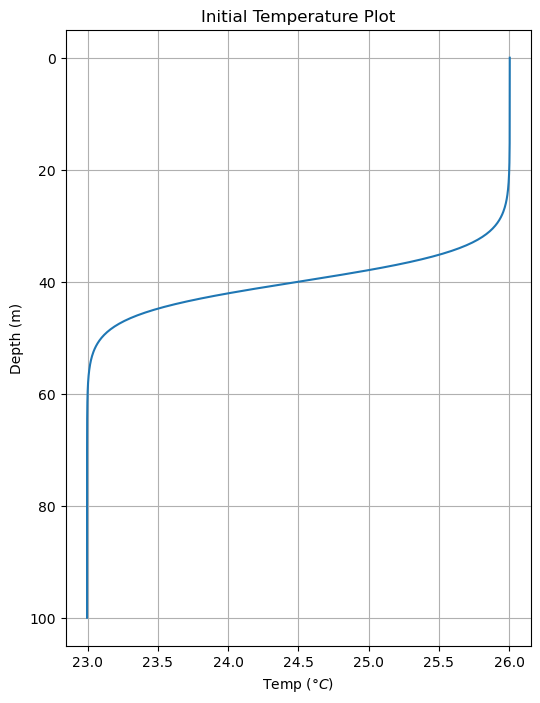

In [6]:
# Check plots to make sure behavior matches expected
plt.figure(figsize=(6, 8))
plt.plot(T, z)
# Invert y-axis 
plt.gca().invert_yaxis()
plt.xlabel(r'Temp ($\degree C$)')
plt.ylabel('Depth (m)')
plt.title('Initial Temperature Plot')
plt.grid()
plt.show()

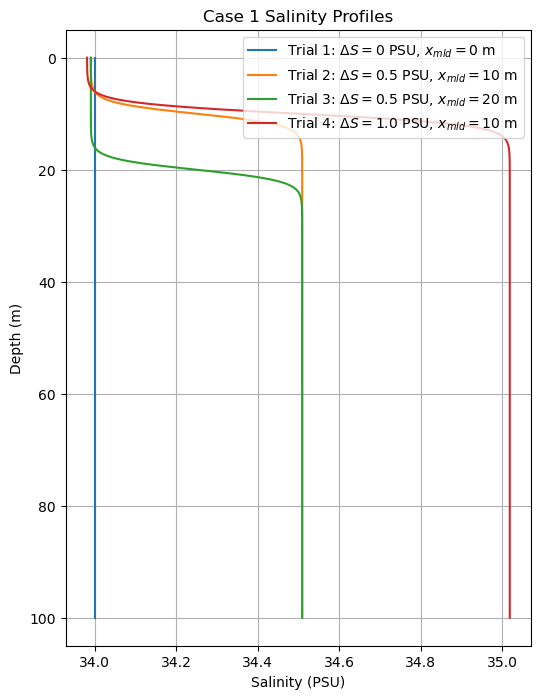

In [265]:
# Check plots to make sure behavior matches expected
plt.figure(figsize=(6, 8))
# Invert y-axis 
plt.gca().invert_yaxis()
plt.xlabel('Salinity (PSU)')
plt.plot(S1, z, label=trial_labels[0])
plt.plot(S2, z, label=trial_labels[1])
plt.plot(S3, z, label=trial_labels[2])
plt.plot(S4, z, label=trial_labels[3])
plt.ylabel('Depth (m)')
plt.title('Case 1 Salinity Profiles')
plt.legend()
plt.grid()
plt.show()

In [8]:
#Function that writes .dat files, gdn is the output directory
def write_profile_dat(filename, depths, values, n_columns=2,  gdn = "profiles/", datetime_str= "2018-04-01 00:00:00 401 2"):
    n_levels = len(depths)
    filepath = os.path.join(gdn, filename)

    with open(filepath, 'w') as f:
        f.write(f"{datetime_str} {n_levels} {n_columns}\n")

        for d, v in zip(depths, values):
            f.write(f"{d} {v}\n")

write_profile_dat("tprof_file.dat", -z, T)
write_profile_dat("sprof_file1.dat", -z, S1)
write_profile_dat("sprof_file2.dat", -z, S2)
write_profile_dat("sprof_file3.dat", -z, S3)
write_profile_dat("sprof_file4.dat", -z, S4)

### Rainfall Profile

In [9]:
time_index = pd.date_range(
    start="2018-04-01 00:00:00",
    end="2018-04-07 23:00:00",
    freq="h"
)

#Wind Stress
taux = [0.1125] * len(time_index)
tauy = [0.0] * len(time_index)
tau_df = pd.DataFrame({"datetime": time_index,"taux": taux, "tauy": tauy})

#Rainfall
np.set_printoptions(precision=10, suppress=False)
rainrate = 10 / 1000 / 3600 #mm/hr -> m/s
rain = np.full(len(time_index), 0)
rain[4:8] = rainrate
rain_df = pd.DataFrame({"datetime": time_index, "rainrate": rain})

#SST
SST = np.full(len(time_index), 26)
sst_df = pd.DataFrame({"datetime": time_index,"SST": SST})

In [10]:
def write_profile_dat(filename, values, gdn="profiles/", datetime_str="2018-04-01 00:00:00", header=True):
    filepath = os.path.join(gdn, filename)
    values = values.values
    n_levels = values.shape[0]
    n_columns = values.shape[1]

    #Open file
    with open(filepath, "w") as f:
        #write header
        if header == True:
            f.write(f"{datetime_str} {n_levels} {n_columns}\n")

        #write each row
        for i in range(n_levels):
            row = list(values[i])
            f.write(" ".join(map(str, row)) + "\n")

write_profile_dat("tau_file.dat", tau_df, header=False)
write_profile_dat("pme_file.dat", rain_df, header=False)
write_profile_dat("sst_file.dat", rain_df, header=False)

---
# Problem 1
#### Data Wrangling

In [11]:
### outputs
# SSS: Sea surface salinity 
# salt: salinity (absolute)
# salt_p: salinity (practical)
# salt_obs: salinity (observed)

res_base = Path("./GOTM/cases/pset3")

ds1 = xr.open_dataset(res_base / "trial_1.nc")
ds2 = xr.open_dataset(res_base / "trial_2.nc")
ds3 = xr.open_dataset(res_base / "trial_3.nc")
ds4 = xr.open_dataset(res_base / "trial_4.nc")
ds_files = [ds1, ds2, ds3, ds4]

#Helper function to pull all of the xarrays
def process_var(varname, ds_files=ds_files, labels=['Trial 1','Trial 2','Trial 3','Trial 4']):
    outputs = []
    for ds in ds_files:
        df = ds[varname].to_dataframe().droplevel(["lat", "lon"])
        indices = df.index.names

        #Convert z point to water depth
        if 'z' in indices:
            df['d'] = ((df.index.get_level_values('z') - 999) / -10)
            #Take absolut value to get absolute rid of slightly negative values
            df['d'] = df['d'].abs()
            df = df.droplevel('z').set_index("d", append=True)
        elif 'zi' in indices:
            #switch from zi to z
            df["d"] = df.index.get_level_values("zi") / 10
            df = df.droplevel("zi").set_index("d", append=True)
        
        outputs.append(df)
    combined_df = pd.concat(outputs, axis = 1)
    combined_df.columns = labels
    return combined_df

In [12]:
#Variables needed for part a)
sss = process_var('sss')
salt = process_var('salt_p')

In [13]:
#Variables needed for part c)
shear = process_var('P')
buoy = process_var('G')
diss = process_var('eps')

In [14]:
#ds1

---
## Part a)

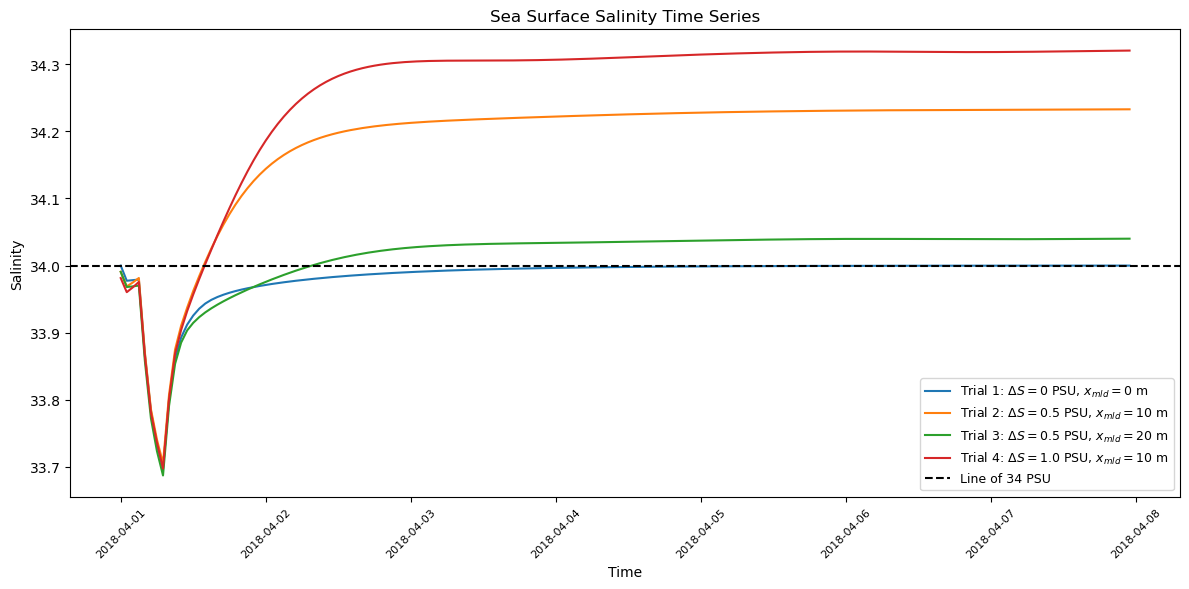

In [266]:
salt_d0 = salt.xs(0, level='d')


plt.figure(figsize=(12, 6))

# Plotting loop
for trial, label in zip(salt_d0.columns, trial_labels):
    plt.plot(salt_d0.index, salt_d0[trial], label=label)
plt.axhline(34, color='black', linestyle='--', label='Line of 34 PSU')

plt.xlabel('Time')
plt.ylabel('Salinity')
plt.title('Sea Surface Salinity Time Series')
plt.legend(fontsize=9)
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

---
# Part b)

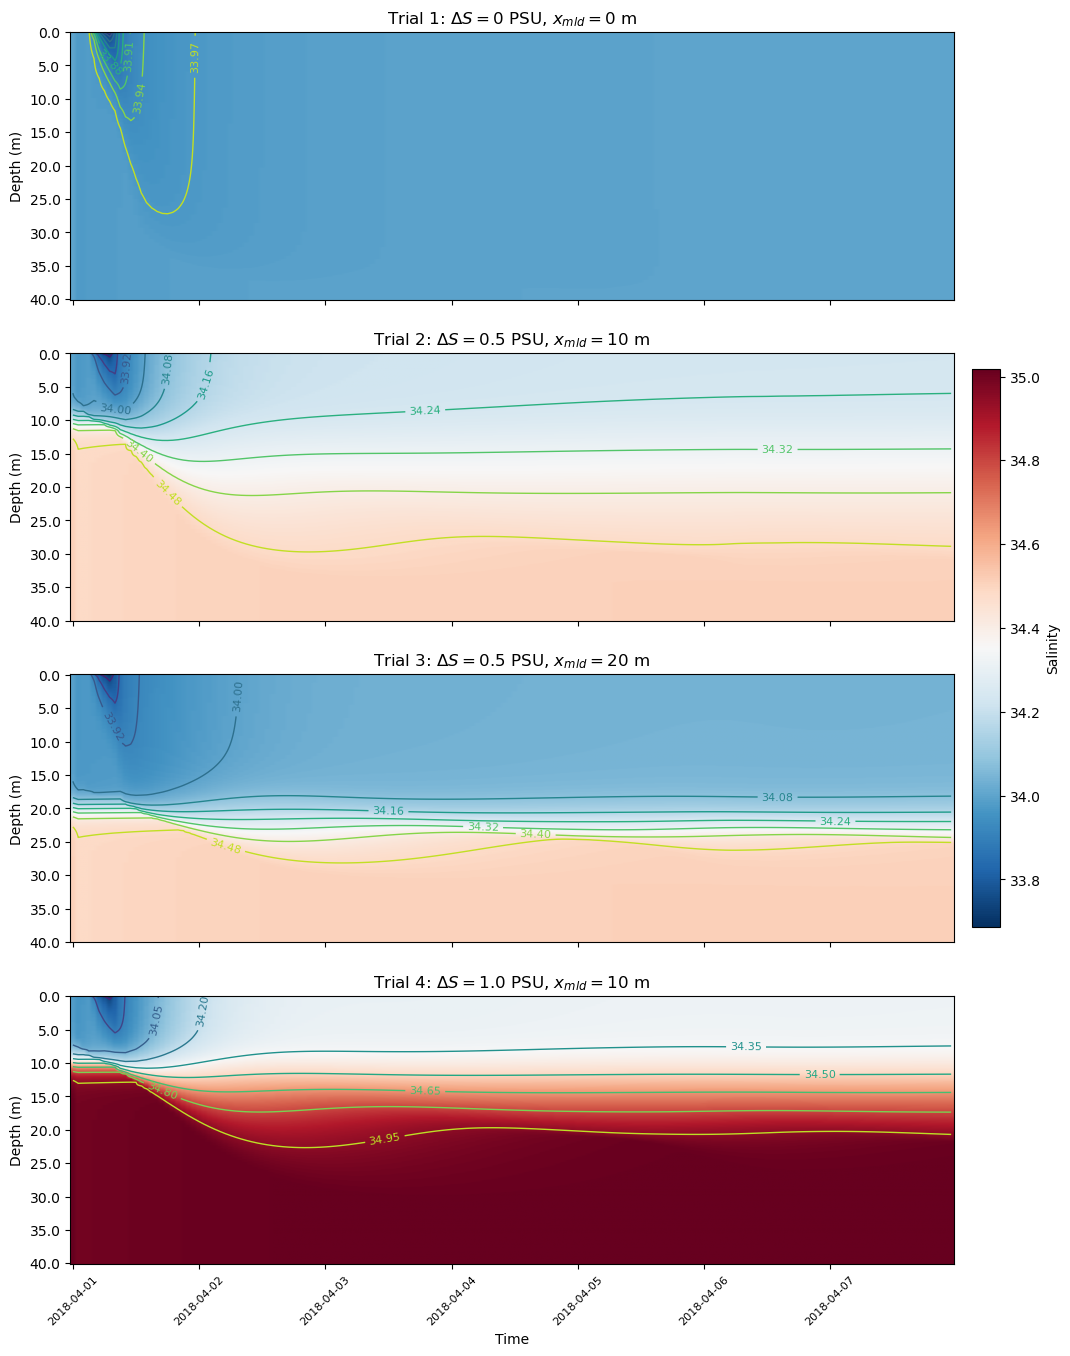

In [199]:
global_min = salt.min().min()
global_max = salt.max().max()

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 16), sharex=True)

for ax, trial, label in zip(axes, salt.columns, trial_labels):
    
    heatmap_data = salt[[trial]].reset_index().pivot(index='d', columns='time', values=trial)
    heatmap_data = heatmap_data.loc[0:40]
    
    im = ax.imshow(
        heatmap_data.values,
        aspect='auto',
        origin='upper',
        cmap='RdBu_r',
        vmin=global_min,  
        vmax=global_max  
    )
    
    X, Y = np.meshgrid(np.arange(heatmap_data.shape[1]), np.arange(heatmap_data.shape[0]))
    contours = ax.contour(X, Y, heatmap_data.values, levels=10, linewidths=1)
    ax.clabel(contours, fontsize=8, fmt="%.2f")
    
    # Only add one colorbar for the whole figure
    if ax == axes[-1]: 
        cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
        cbar.set_label('Salinity')
    
    ax.set_title(label)
    ax.set_ylabel('Depth (m)')
    z_values = heatmap_data.index
    y_ticks = np.arange(0, len(z_values), 50)
    y_labels = [z_values[i] for i in y_ticks]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

time_values = heatmap_data.columns
time_days = pd.to_datetime(time_values).normalize().drop_duplicates()
x_ticks = [heatmap_data.columns.get_loc(t) for t in time_days]
axes[-1].set_xticks(x_ticks)
axes[-1].set_xticklabels([t.strftime('%Y-%m-%d') for t in time_days], rotation=45, fontsize=8)
axes[-1].set_xlabel('Time')

#plt.tight_layout()
plt.show()

--- 
## Part c)

In [258]:
energy = pd.concat(
    {'Shear': shear,'Buoy': buoy,'Dissipation': diss},axis=1)
energy.columns.names = ['variable', 'trial']


trial_data1 = {}
for trial in energy.columns.get_level_values('trial').unique():
    df = energy.xs(trial, level='trial', axis=1).copy()
    df = df.rename(columns={'Shear': 'shear','Buoy': 'buoy', 'Dissipation': 'diss'})
    #tke
    df['net'] = df['shear'] + df['buoy'] - df['diss']
    trial_data1[trial] = df

for trial, df in trial_data1.items():
    print(trial)
    print(df[['shear','buoy','diss']].abs().max())
    print(df[['shear','buoy','diss']].mean())

    print()

Trial 1
variable
shear    2.848020e-05
buoy     6.467645e-07
diss     7.165610e-05
dtype: float32
variable
shear    1.806395e-07
buoy    -4.615113e-09
diss     2.470381e-07
dtype: float32

Trial 2
variable
shear    2.848982e-05
buoy     6.473609e-07
diss     7.165610e-05
dtype: float32
variable
shear    2.490679e-07
buoy    -2.437845e-08
diss     2.957810e-07
dtype: float32

Trial 3
variable
shear    2.848592e-05
buoy     6.466524e-07
diss     7.165610e-05
dtype: float32
variable
shear    1.897172e-07
buoy    -1.038263e-08
diss     2.504166e-07
dtype: float32

Trial 4
variable
shear    2.849075e-05
buoy     6.469814e-07
diss     7.165610e-05
dtype: float32
variable
shear    2.509523e-07
buoy    -2.581018e-08
diss     2.962501e-07
dtype: float32



In [270]:
ratio_data = {}

for trial, df in trial_data1.items():
    P = df['shear'] + df['buoy']
    D = df['diss']

    ratio = (P - D) / (D + 1e-12)

    ratio_data[trial] = (
        ratio.reset_index()
        .pivot(index='d', columns='time', values=0)
    )

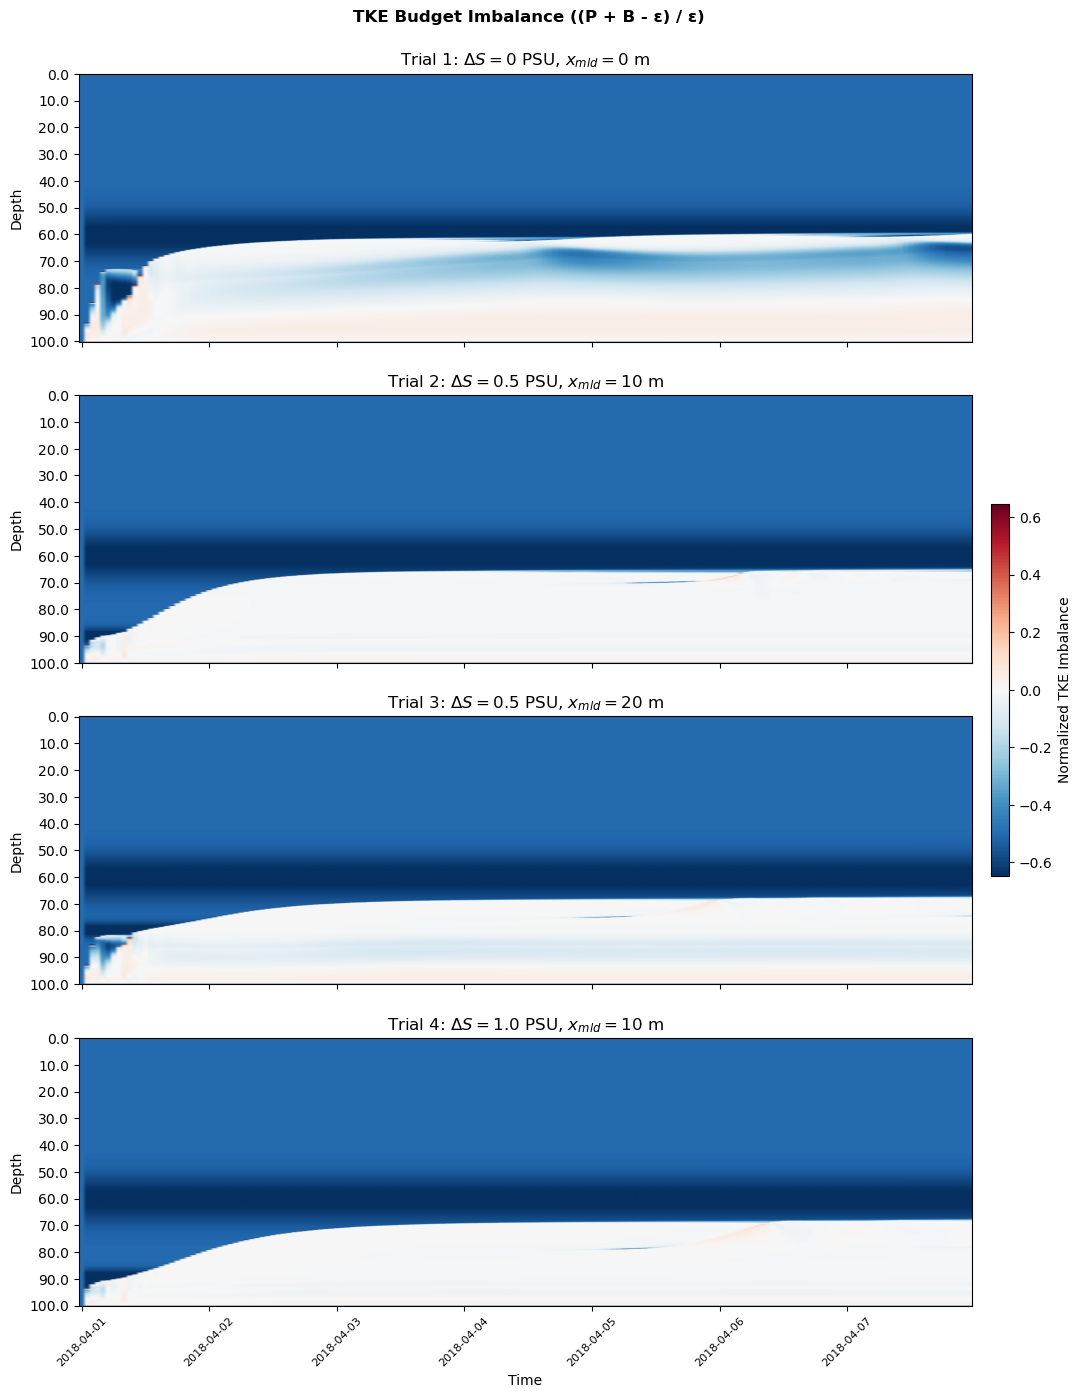

In [271]:
all_vals = np.concatenate([v.values.flatten() for v in ratio_data.values()])
vmax = np.nanpercentile(np.abs(all_vals), 95)
vmin = -vmax

fig, axes = plt.subplots(
    nrows=len(ratio_data),
    ncols=1,
    figsize=(12, 4 * len(ratio_data)),
    sharex=True,
    sharey=True
)

if len(ratio_data) == 1:
    axes = [axes]

for ax, (trial, heatmap), label in zip(axes, ratio_data.items(), trial_labels):

    im = ax.imshow(
        heatmap.values,
        cmap='RdBu_r',
        origin='upper',
        aspect='auto',
        vmin=vmin,
        vmax=vmax
    )

    X, Y = np.meshgrid(
        np.arange(heatmap.shape[1]),
        np.arange(heatmap.shape[0])
    )

    ax.set_title(f'{label}')
    ax.set_ylabel('Depth')

    z = heatmap.index
    yt = np.arange(0, len(z), 100)
    ax.set_yticks(yt)
    ax.set_yticklabels([z[i] for i in yt])

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('Normalized TKE Imbalance')

time_values = list(ratio_data.values())[0].columns
time_days = pd.to_datetime(time_values).normalize().drop_duplicates()
x_ticks = [list(ratio_data.values())[0].columns.get_loc(t) for t in time_days]

axes[-1].set_xticks(x_ticks)
axes[-1].set_xticklabels(
    [t.strftime('%Y-%m-%d') for t in time_days],
    rotation=45,
    fontsize=8
)
axes[-1].set_xlabel('Time')

fig.suptitle(f'TKE Budget Imbalance ((P + B - ε) / ε)', y=.92, fontweight='bold')
#plt.tight_layout()
plt.show()

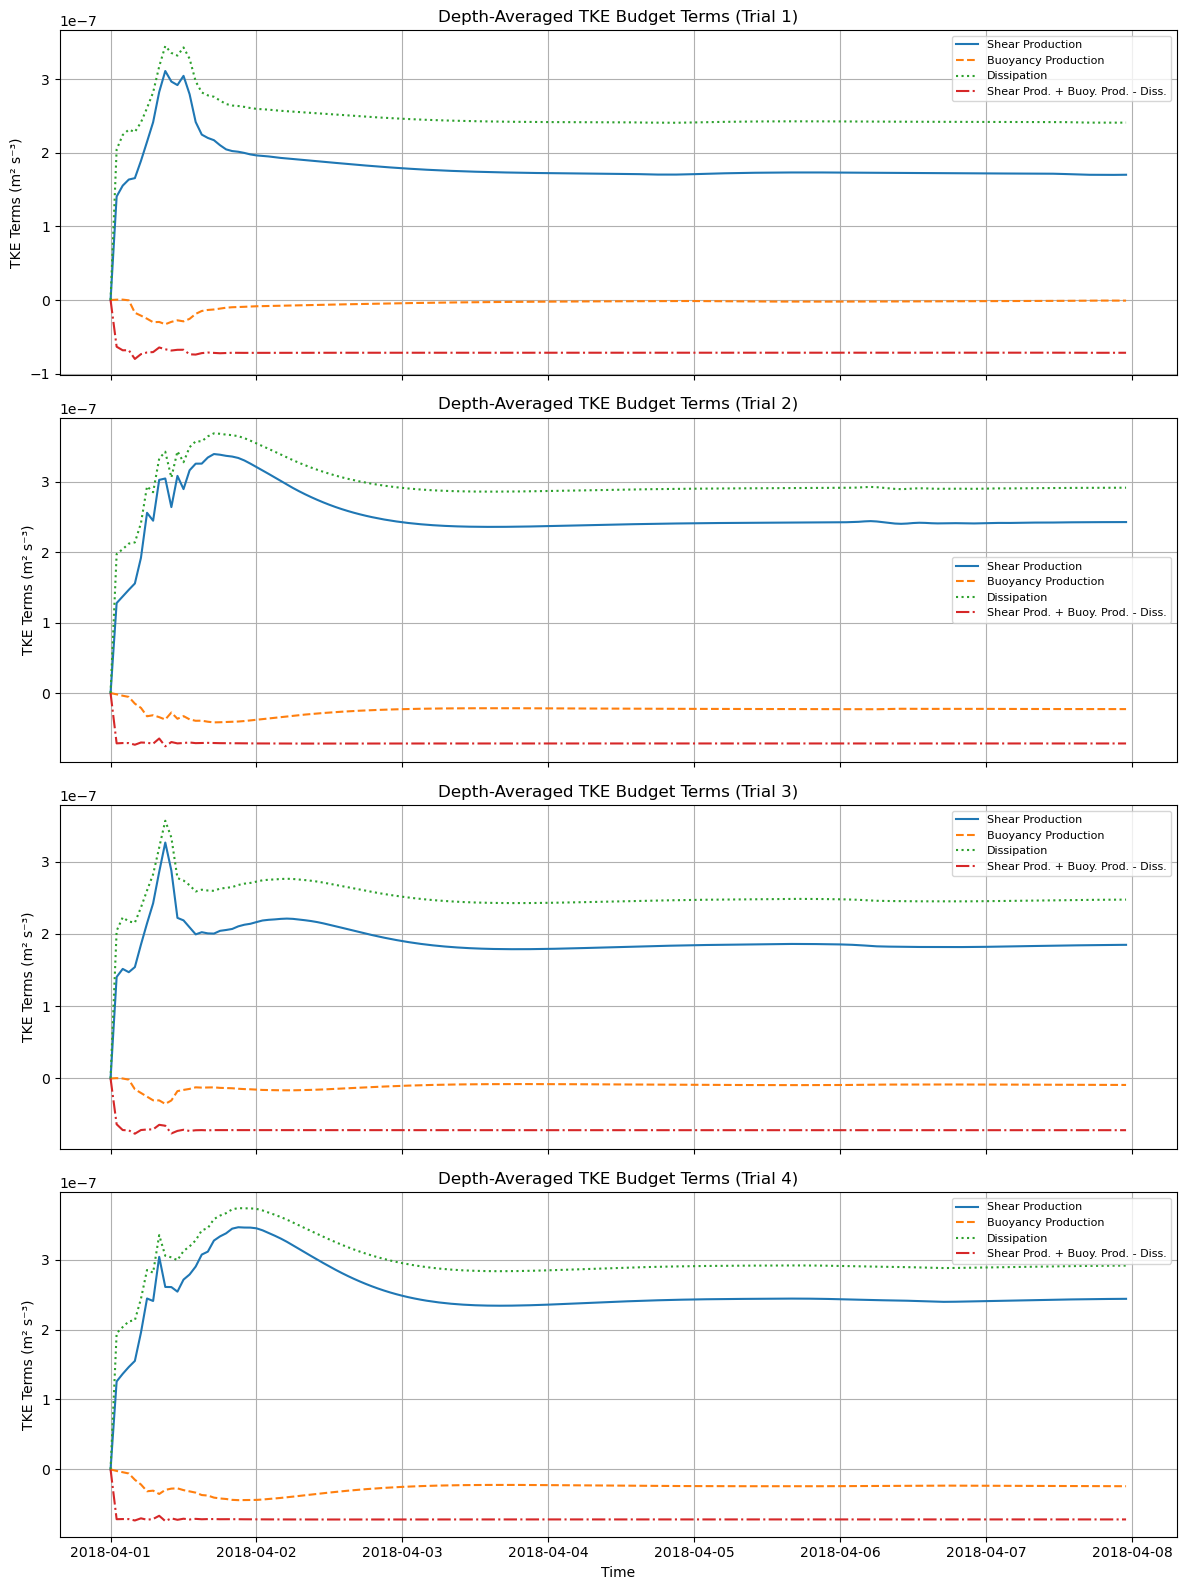

In [275]:
fig, axes = plt.subplots(
    nrows=len(trial_data1),
    ncols=1,
    figsize=(12, 4 * len(trial_data1)),
    sharex=True
)

if len(trial_data1) == 1:
    axes = [axes]

for ax, (trial, df) in zip(axes, trial_data1.items()):
    shear_avg = df['shear'].groupby(df.index.get_level_values('time')).mean()
    buoy_avg = df['buoy'].groupby(df.index.get_level_values('time')).mean()
    diss_avg = df['diss'].groupby(df.index.get_level_values('time')).mean()
    
    ax.plot(shear_avg.index, shear_avg.values, label='Shear Production', linestyle='-')
    ax.plot(buoy_avg.index, buoy_avg.values, label='Buoyancy Production', linestyle='--')
    ax.plot(diss_avg.index, diss_avg.values, label='Dissipation', linestyle=':')
    ax.plot(shear_avg.index, (shear_avg.values - diss_avg.values + buoy_avg.values), label='Shear Prod. + Buoy. Prod. - Diss.', linestyle='dashdot')

    
    ax.set_title(f'Depth-Averaged TKE Budget Terms ({trial})')
    ax.set_ylabel('TKE Terms (m² s⁻³)')
    ax.grid(True)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Time')

plt.tight_layout()
plt.show()

---
---
---
# Question 2:
## Housekeeping

$$
Q_{sw}(t) =
\begin{cases}
1000\ \mathrm{W\,m^{-2}} \cdot \sin\left(\dfrac{\pi t}{12\ \mathrm{hr}}\right), & 0 \leq t \leq 12\ \mathrm{hr} \\
0, & 12\ \mathrm{hr} < t \leq 24\ \mathrm{hr}
\end{cases}
$$

In [226]:
#Get hours out of datetime
t_hours = time_index.hour + time_index.minute / 60
#initialize empty array
Q_sw = np.zeros(len(time_index))
#apply piecewise equation
mask = (t_hours >= 0) & (t_hours <= 12)
Q_sw[mask] = 1000 * np.sin(np.pi * t_hours[mask] / 12)
Q_df = pd.DataFrame({'datetime': time_index, 'Q_sw' : Q_sw})
#Save to .dat file
write_profile_dat('qsw_prof.dat', Q_df, header=False)

In [289]:
res_base = Path("./GOTM/cases/pset3_p2")

ds1 = xr.open_dataset(res_base / "trial_1.nc")
ds2 = xr.open_dataset(res_base / "trial_2.nc")
ds_files2 = [ds1, ds2]

l_short = ["Trial 1" , "Trial 2"]
labels2 = ['Trial 1 ($u_{10}=3ms^{-1}$)', 'Trial 2 ($u_{10}=6ms^{-1}$)']

#Temperature info for Parts a) and b)
sst = process_var('temp', ds_files=ds_files2, labels=l_short)
sst_d0 = sst.xs(0, level='d')

#Current info for Part c)
u = process_var('u', ds_files=ds_files2, labels=l_short)
v = process_var('v', ds_files=ds_files2, labels=l_short)
current = pd.concat([u,v], axis = 1)
current.columns = ["u Trial 1" , "u Trial 2", "v Trial 1" , "v Trial 2"]

#Turbulence info for Part d)
p2 = process_var('P', ds_files=ds_files2, labels=l_short)
g2 = process_var('G', ds_files=ds_files2, labels=l_short)
eps2 = process_var('eps', ds_files=ds_files2, labels=l_short)
energy2 = pd.concat([p2,g2,eps2], axis = 1)
energy2.columns = ["Shear Trial 1" , "Shear Trial 2", "Buoy Trial 1" , "Buoy Trial 2", "Dissipation Trial 1", "Dissipation Trial 2"]

#Convert to multi-index for easier slicing
new_cols = energy2.columns.str.extract(r'^(.*?)\s+(Trial[_ ]?\d+)$')
new_cols[1] = new_cols[1].str.replace('_', ' ')
energy2.columns = pd.MultiIndex.from_frame(new_cols)
energy2.columns.names = ['variable', 'trial']

#### Solar Radiation Sanity Check

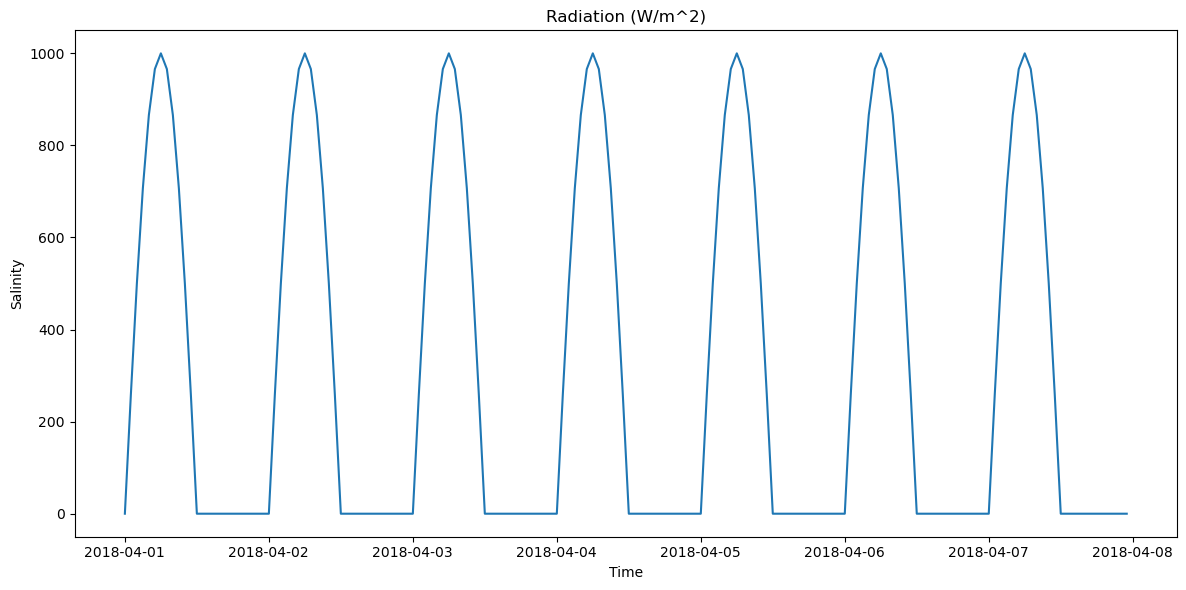

In [228]:
plt.figure(figsize=(12, 6))
plt.plot(time_index, Q_sw)
plt.xlabel('Time')
plt.ylabel('Salinity')
plt.title('Radiation (W/m^2)')
plt.tight_layout()
plt.show()

---
## Part a)

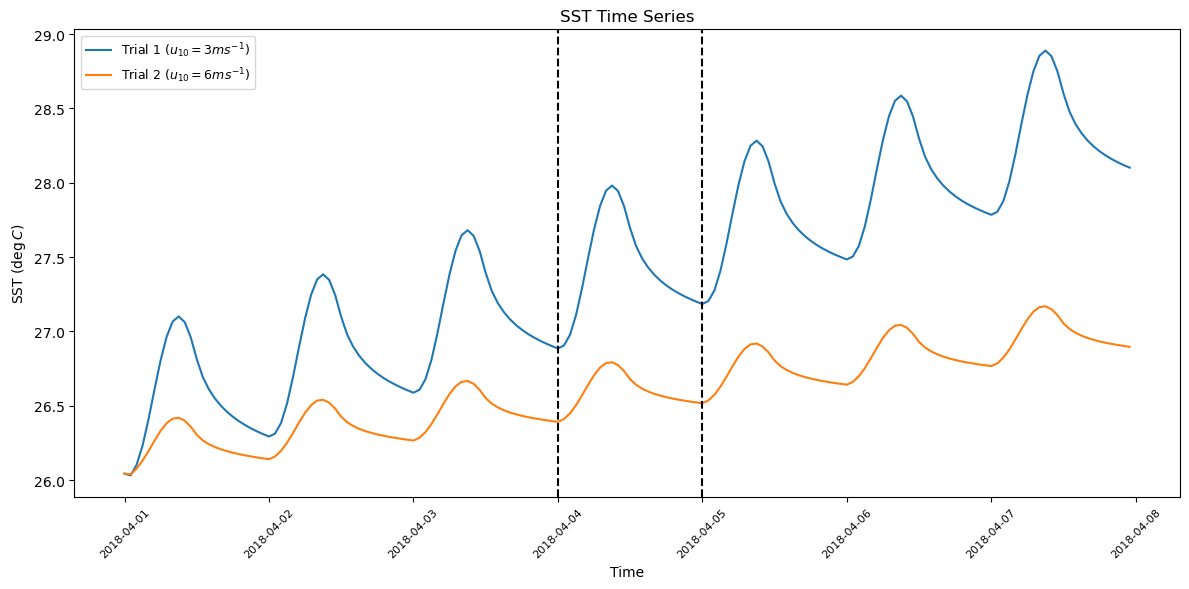

In [285]:
plt.figure(figsize=(12, 6))

for col, label in zip(sst_d0.columns, labels2):
    plt.plot(sst_d0.index, sst_d0[col], label=label)
plt.axvline(pd.to_datetime('2018-04-04'), color='black', linestyle='--', linewidth=1.5)
plt.axvline(pd.to_datetime('2018-04-05'), color='black', linestyle='--', linewidth=1.5)

plt.xlabel('Time')
plt.ylabel(r'SST ($\deg C$)')
plt.title('SST Time Series')
plt.legend(fontsize=9)
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

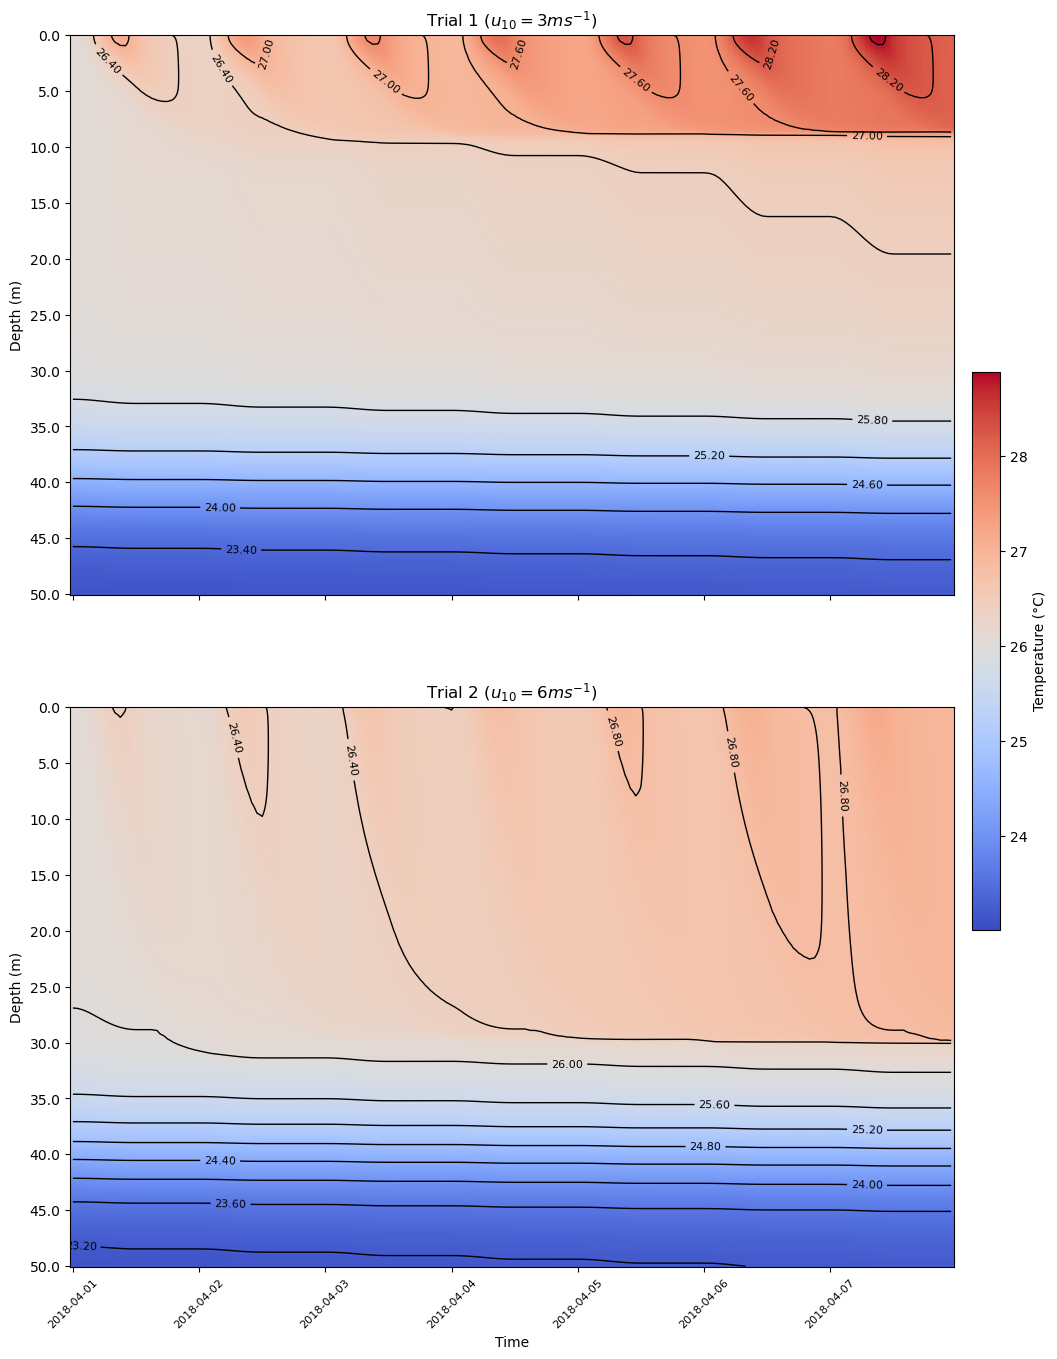

In [230]:
global_min = sst.min().min()
global_max = sst.max().max()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 16), sharex=True)

for ax, trial, label in zip(axes, sst.columns, labels2):
    
    # Pivot the data
    heatmap_data = sst[[trial]].reset_index().pivot(index='d', columns='time', values=trial)
    heatmap_data = heatmap_data.loc[0:50]  # adjust depth range if needed
    
    im = ax.imshow(
        heatmap_data.values,
        aspect='auto',
        origin='upper',
        cmap='coolwarm',
        vmin=global_min,
        vmax=global_max
    )
    
    # contours
    X, Y = np.meshgrid(np.arange(heatmap_data.shape[1]), np.arange(heatmap_data.shape[0]))
    contours = ax.contour(X, Y, heatmap_data.values, levels=10, linewidths=1, colors='k')
    ax.clabel(contours, fontsize=8, fmt="%.2f")
    
    if ax == axes[-1]:
        cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
        cbar.set_label('Temperature (°C)')
    
    ax.set_title(label)
    ax.set_ylabel('Depth (m)')
    
    z_values = heatmap_data.index
    y_ticks = np.arange(0, len(z_values), 50)
    y_labels = [z_values[i] for i in y_ticks]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

time_values = heatmap_data.columns
time_days = pd.to_datetime(time_values).normalize().drop_duplicates()
x_ticks = [heatmap_data.columns.get_loc(t) for t in time_days]
axes[-1].set_xticks(x_ticks)
axes[-1].set_xticklabels([t.strftime('%Y-%m-%d') for t in time_days], rotation=45, fontsize=8)
axes[-1].set_xlabel('Time')

plt.show()

---
# Part b)

In [276]:
#slice the maximum and minimum SST indexes for one day
## You can print the results if desired, but the max happens at the same time stamp
### for both trials
sst_d0_slice = sst_d0.loc['2018-04-04 00:00:00' : '2018-04-05 00:00:00']
max_times = sst_d0_slice.idxmax()
min_times = sst_d0_slice.idxmin()

max_idx = sst_d0_slice.iloc[:, 0].idxmax()
min_idx = sst_d0_slice.iloc[:, 0].idxmin()

idx = pd.IndexSlice 
sst_max = sst.loc[idx[max_idx, :], :] 
sst_min = sst.loc[idx[min_idx, :], :]

sst_max_vals = sst_max.xs(0.0, level='d')
sst_min_vals = sst_min.xs(0.0, level='d')

delta_sst = (sst_max_vals.values - sst_min_vals.values).squeeze()
print(f"Diurnal Change in SST for Trial 1: {delta_sst[0]:.2f} °C")
print(f"Diurnal Change in SST for Trial 2: {delta_sst[1]:.2f} °C")

Diurnal Change in SST for Trial 1: 1.10 °C
Diurnal Change in SST for Trial 2: 0.40 °C


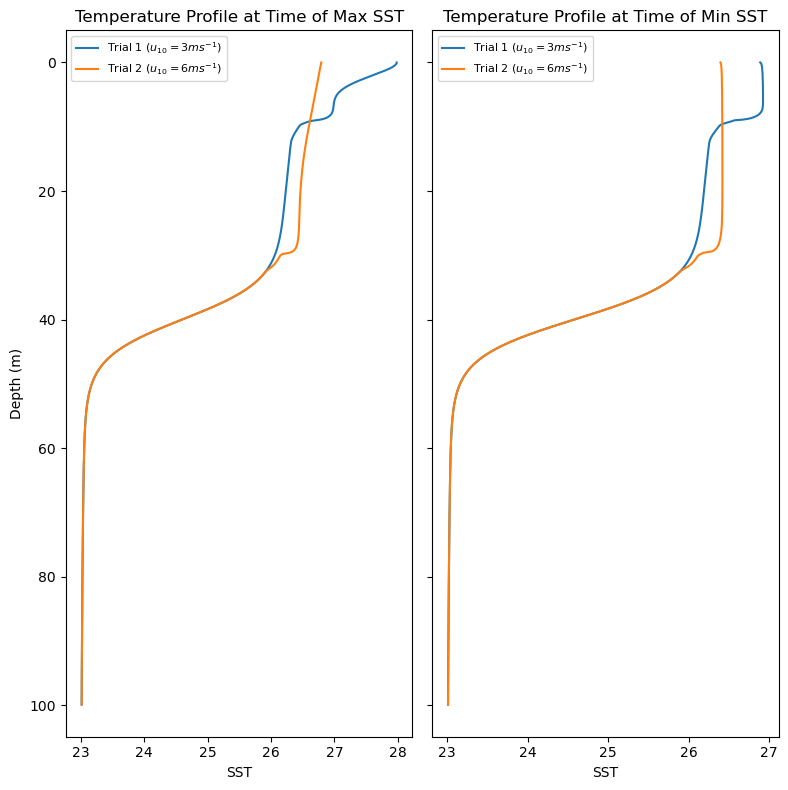

In [277]:
fig, axes = plt.subplots(ncols=2, figsize=(8, 8), sharey=True)

#max
ax = axes[0]
for i in range(len(sst_max.columns)):
    profile = sst_max.iloc[:, i]
    d_values = profile.index.get_level_values('d').to_numpy()
    ax.plot(profile.values, d_values, label=labels2[i])

ax.set_xlabel('SST')
ax.set_ylabel('Depth (m)')
ax.set_title('Temperature Profile at Time of Max SST')
ax.legend(fontsize=8)

#min
ax = axes[1]
for i in range(len(sst_min.columns)):
    profile = sst_min.iloc[:, i]
    d_values = profile.index.get_level_values('d').to_numpy()
    ax.plot(profile.values, d_values, label=labels2[i])

ax.invert_yaxis()
ax.set_xlabel('SST')
ax.set_title('Temperature Profile at Time of Min SST')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Part c)

In [278]:
idx = pd.IndexSlice 
u_max = u.loc[idx[max_idx, :], :] 
u_min = u.loc[idx[min_idx, :], :]
v_max = v.loc[idx[max_idx, :], :] 
v_min = v.loc[idx[min_idx, :], :]

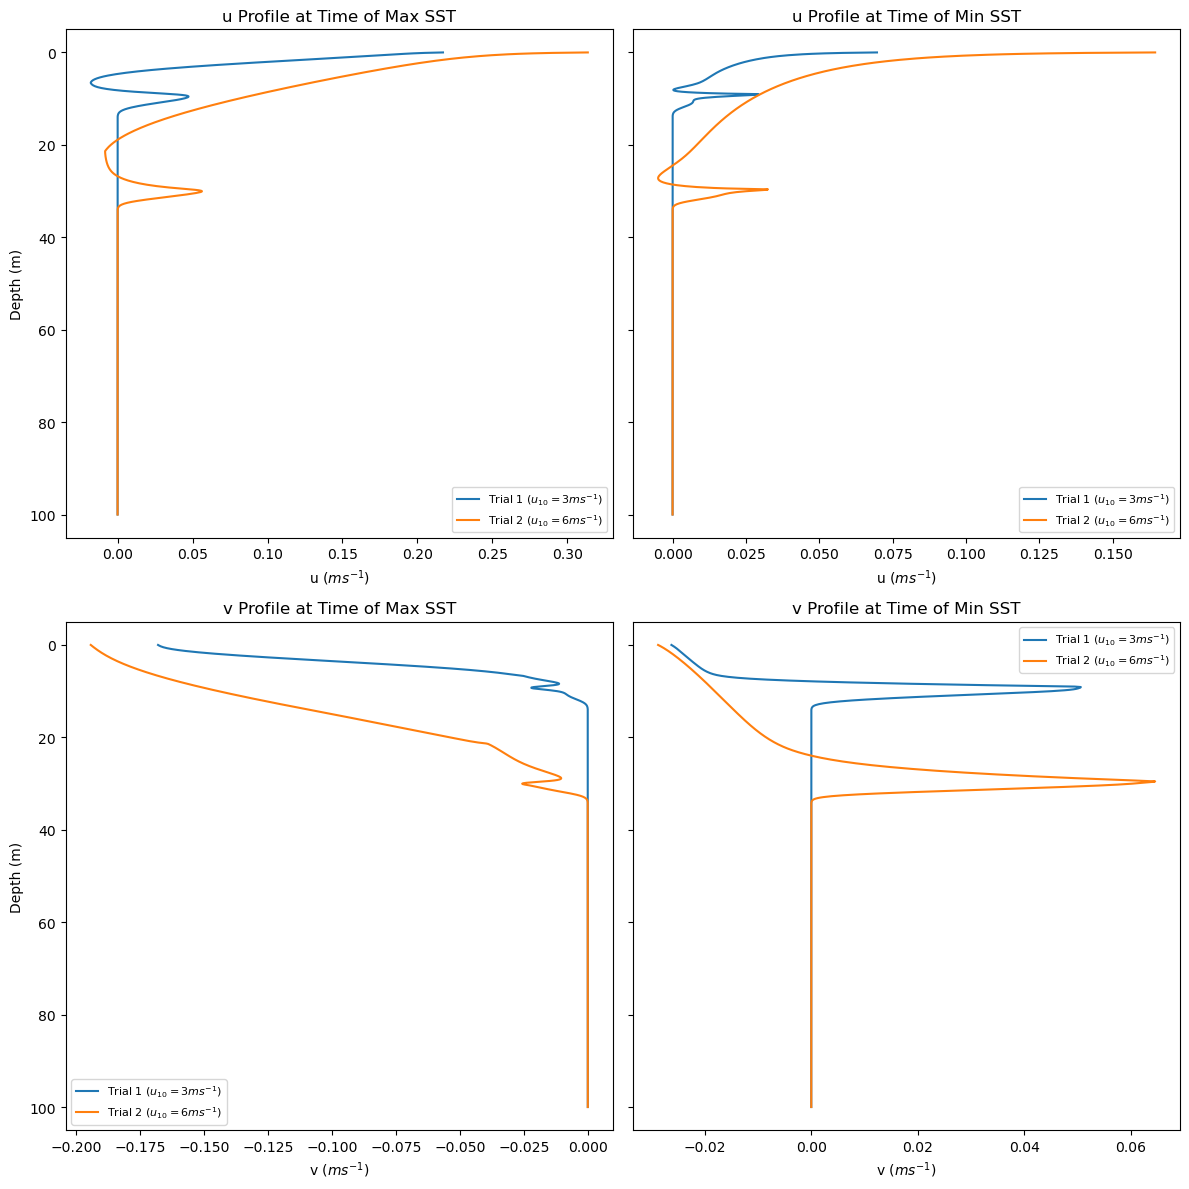

In [279]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12), sharey=True)

def plot_profiles(ax, data, xlabel, title, invert=False):
    for i in range(len(data.columns)):
        profile = data.iloc[:, i]
        d_values = profile.index.get_level_values('d').to_numpy()
        ax.plot(profile.values, d_values, label=labels2[i])
    if invert:
        ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

# u max
plot_profiles(axes[0, 0], u_max, r'u ($ms^{-1}$)','u Profile at Time of Max SST')
axes[0, 0].set_ylabel('Depth (m)')

# u min
plot_profiles(axes[0, 1],u_min,r'u ($ms^{-1}$)','u Profile at Time of Min SST', invert=True)

# v max
plot_profiles(axes[1, 0],v_max,r'v ($ms^{-1}$)','v Profile at Time of Max SST')
axes[1, 0].set_ylabel('Depth (m)')

# v min
plot_profiles(axes[1, 1],v_min,r'v ($ms^{-1}$)','v Profile at Time of Min SST')

plt.tight_layout()
plt.show()

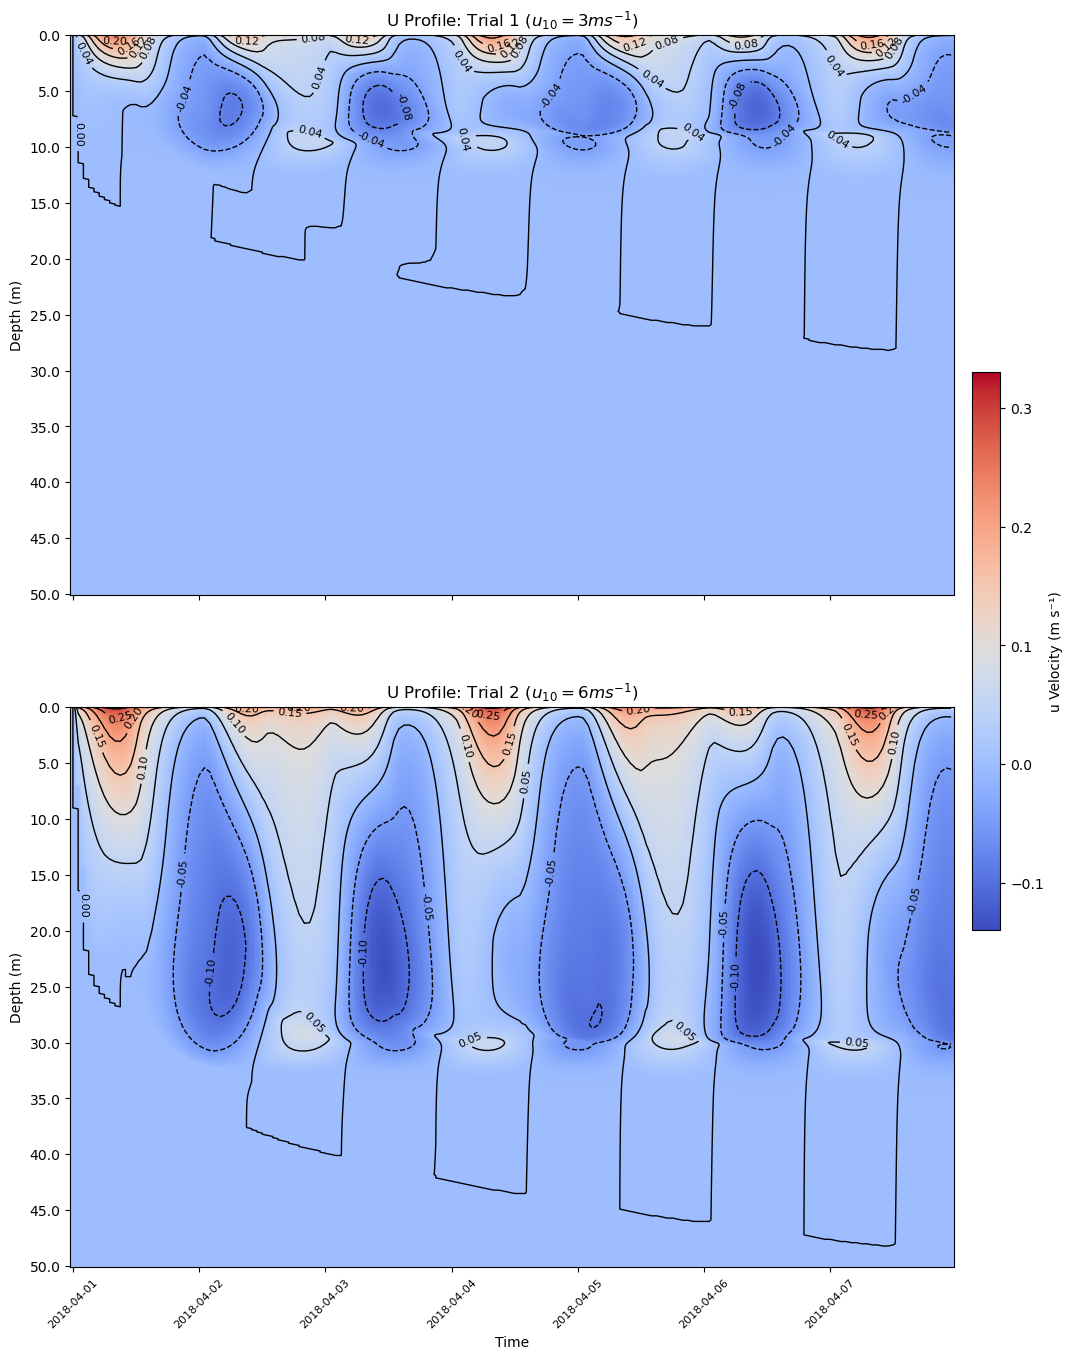

In [280]:
global_min = u.min().min()
global_max = u.max().max()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 16), sharex=True)

for ax, trial, label in zip(axes, u.columns, labels2):
    
    heatmap_data = u[[trial]].reset_index().pivot(index='d', columns='time', values=trial)
    heatmap_data = heatmap_data.loc[0:50]  # depth range

    im = ax.imshow(
        heatmap_data.values,
        aspect='auto',
        origin='upper',
        cmap='coolwarm',
        vmin=global_min,
        vmax=global_max
    )
    
    X, Y = np.meshgrid(np.arange(heatmap_data.shape[1]), np.arange(heatmap_data.shape[0]))
    contours = ax.contour(X, Y, heatmap_data.values, levels=10, linewidths=1, colors='k')
    ax.clabel(contours, fontsize=8, fmt="%.2f")
    
    if ax == axes[-1]:
        cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
        cbar.set_label('u Velocity (m s⁻¹)')
    
    ax.set_title(f'U Profile: {label}')
    ax.set_ylabel('Depth (m)')
    
    z_values = heatmap_data.index
    y_ticks = np.arange(0, len(z_values), 50)
    y_labels = [z_values[i] for i in y_ticks]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

time_values = heatmap_data.columns
time_days = pd.to_datetime(time_values).normalize().drop_duplicates()
x_ticks = [heatmap_data.columns.get_loc(t) for t in time_days]
axes[-1].set_xticks(x_ticks)
axes[-1].set_xticklabels([t.strftime('%Y-%m-%d') for t in time_days], rotation=45, fontsize=8)
axes[-1].set_xlabel('Time')

plt.show()

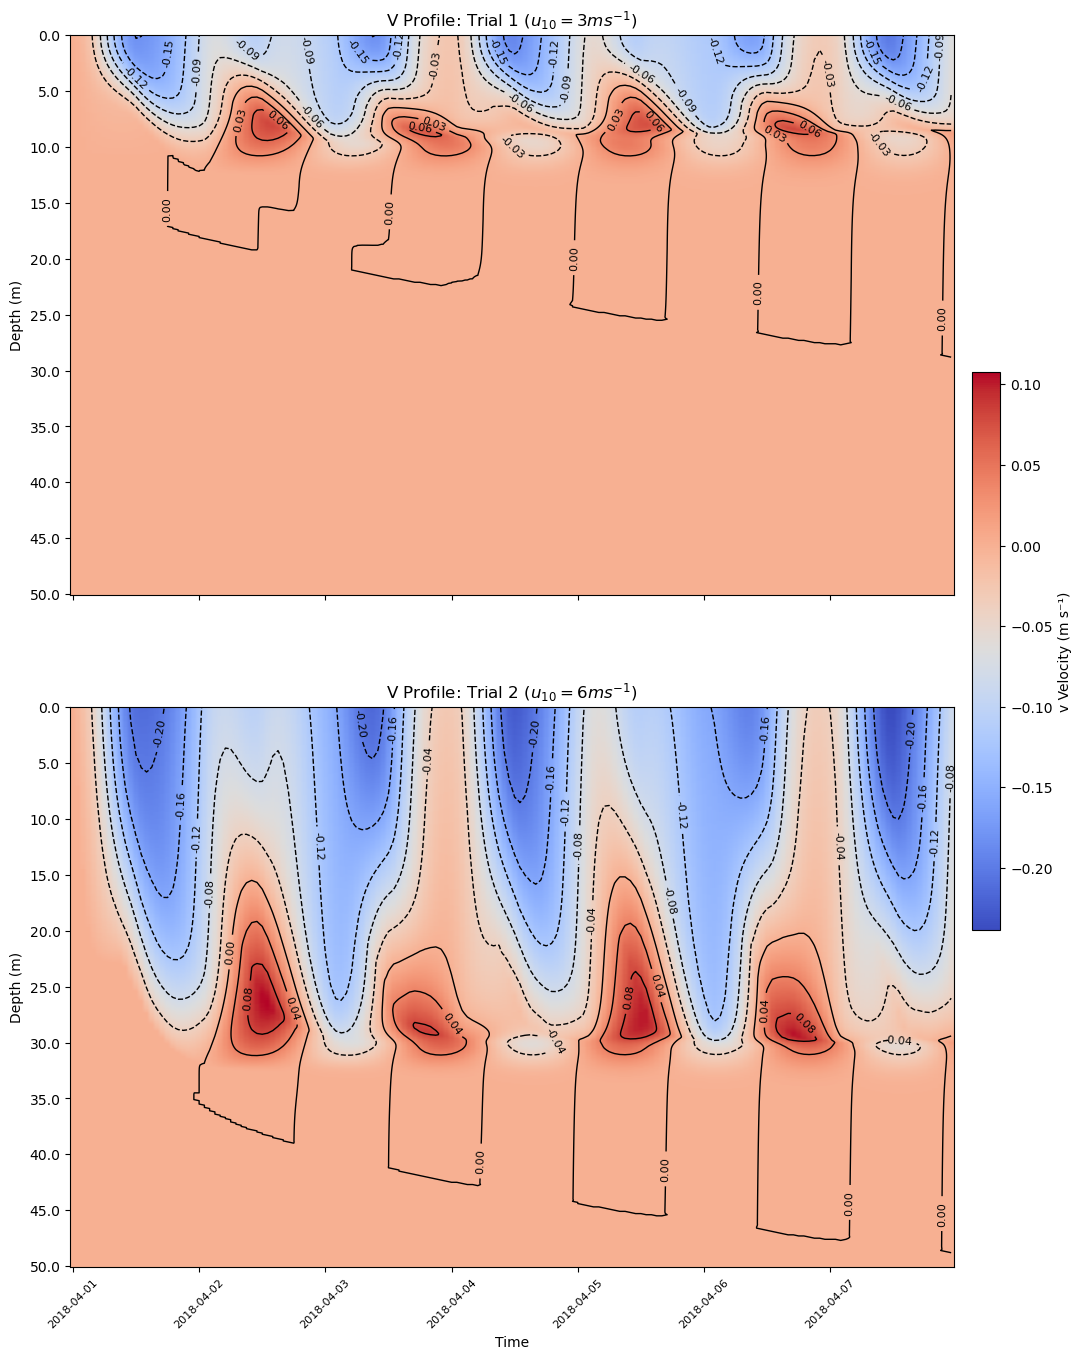

In [281]:
global_min = v.min().min()
global_max = v.max().max()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 16), sharex=True)

for ax, trial, label in zip(axes, v.columns, labels2):
    
    heatmap_data = v[[trial]].reset_index().pivot(index='d', columns='time', values=trial)
    heatmap_data = heatmap_data.loc[0:50]  # depth range

    im = ax.imshow(
        heatmap_data.values,
        aspect='auto',
        origin='upper',
        cmap='coolwarm',
        vmin=global_min,
        vmax=global_max
    )
    
    X, Y = np.meshgrid(np.arange(heatmap_data.shape[1]), np.arange(heatmap_data.shape[0]))
    contours = ax.contour(X, Y, heatmap_data.values, levels=10, linewidths=1, colors='k')
    ax.clabel(contours, fontsize=8, fmt="%.2f")
    
    if ax == axes[-1]:
        cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
        cbar.set_label('v Velocity (m s⁻¹)')
    
    ax.set_title(f'V Profile: {label}')
    ax.set_ylabel('Depth (m)')
    
    z_values = heatmap_data.index
    y_ticks = np.arange(0, len(z_values), 50)
    y_labels = [z_values[i] for i in y_ticks]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

time_values = heatmap_data.columns
time_days = pd.to_datetime(time_values).normalize().drop_duplicates()
x_ticks = [heatmap_data.columns.get_loc(t) for t in time_days]
axes[-1].set_xticks(x_ticks)
axes[-1].set_xticklabels([t.strftime('%Y-%m-%d') for t in time_days], rotation=45, fontsize=8)
axes[-1].set_xlabel('Time')

plt.show()

---
## Part d)

In [282]:
grouped = energy2.T.groupby(level='trial')

trial_data = {}

for trial, group in grouped:
    df = group.T.copy()
    df.columns = [var for var, _ in df.columns]

    # components
    df['shear'] = df['Shear']
    df['buoy'] = df['Buoy']
    df['diss'] = df['Dissipation']
    df['net'] = df['shear'] + df['buoy'] - df['diss']

    trial_data[trial] = df

for trial, df in trial_data.items():
    print(trial)
    print(df[['shear','buoy','diss']].abs().max())
    print(df[['shear','buoy','diss']].mean())
    print()

Trial 1
shear    3.378251e-06
buoy     2.265736e-07
diss     8.957012e-06
dtype: float32
shear    2.705106e-08
buoy    -2.492424e-09
diss     3.342821e-08
dtype: float32

Trial 2
shear    2.588584e-05
buoy     2.983313e-07
diss     7.165610e-05
dtype: float32
shear    1.965205e-07
buoy    -1.137304e-08
diss     2.561592e-07
dtype: float32



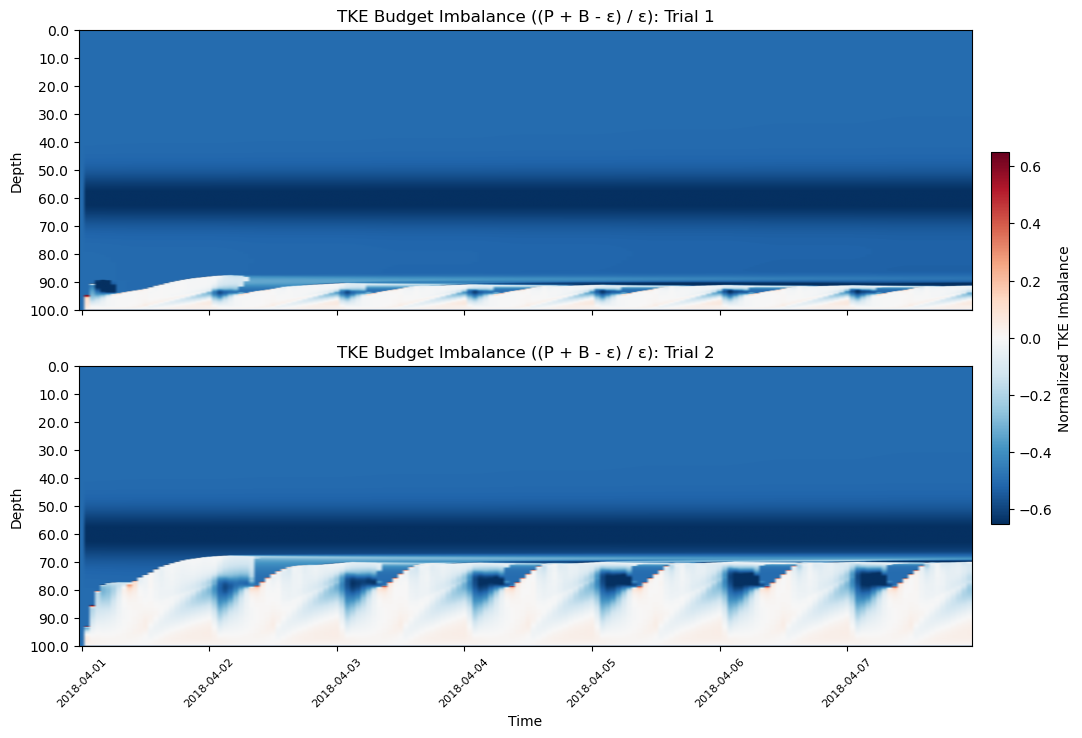

In [283]:
ratio_data = {}

for trial, df in trial_data.items():
    P = df['Shear'] + df['Buoy']
    D = df['Dissipation']

    ratio = (P - D) / (D + 1e-12)

    ratio_data[trial] = (
        ratio.reset_index()
        .pivot(index='d', columns='time', values=0)
    )

all_vals = np.concatenate([v.values.flatten() for v in ratio_data.values()])
vmax = np.nanpercentile(np.abs(all_vals), 95)
vmin = -vmax

fig, axes = plt.subplots(
    nrows=len(ratio_data),
    ncols=1,
    figsize=(12, 4 * len(ratio_data)),
    sharex=True,
    sharey=True
)

if len(ratio_data) == 1:
    axes = [axes]

for ax, (trial, heatmap) in zip(axes, ratio_data.items()):

    im = ax.imshow(
        heatmap.values,
        cmap='RdBu_r',
        origin='upper',
        aspect='auto',
        vmin=vmin,
        vmax=vmax
    )

    X, Y = np.meshgrid(
        np.arange(heatmap.shape[1]),
        np.arange(heatmap.shape[0])
    )

    ax.set_title(f'TKE Budget Imbalance ((P + B - ε) / ε): {trial}')
    ax.set_ylabel('Depth')

    z = heatmap.index
    yt = np.arange(0, len(z), 100)
    ax.set_yticks(yt)
    ax.set_yticklabels([z[i] for i in yt])

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('Normalized TKE Imbalance')

time_values = list(ratio_data.values())[0].columns
time_days = pd.to_datetime(time_values).normalize().drop_duplicates()
x_ticks = [list(ratio_data.values())[0].columns.get_loc(t) for t in time_days]

axes[-1].set_xticks(x_ticks)
axes[-1].set_xticklabels(
    [t.strftime('%Y-%m-%d') for t in time_days],
    rotation=45,
    fontsize=8
)
axes[-1].set_xlabel('Time')

#plt.tight_layout()
plt.show()

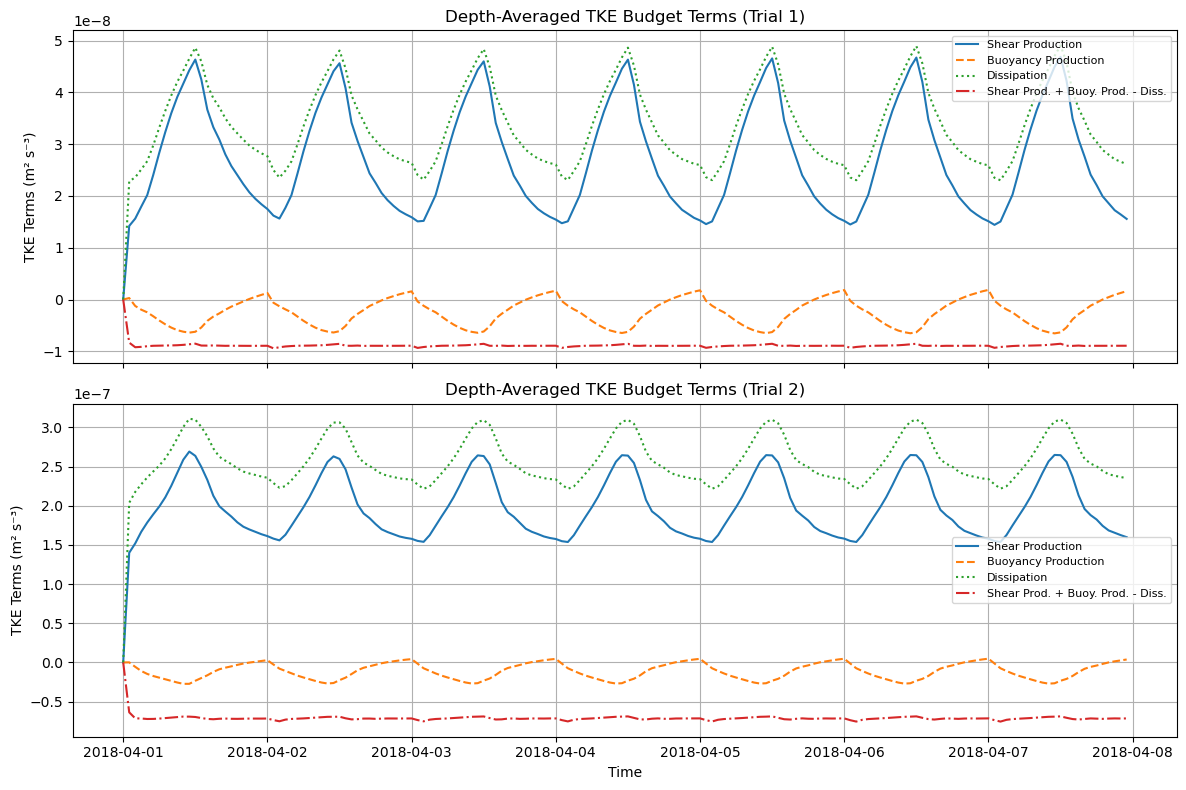

In [284]:
fig, axes = plt.subplots(
    nrows=len(trial_data),
    ncols=1,
    figsize=(12, 4 * len(trial_data)),
    sharex=True
)

if len(trial_data) == 1:
    axes = [axes]

for ax, (trial, df) in zip(axes, trial_data.items()):
    shear_avg = df['shear'].groupby(df.index.get_level_values('time')).mean()
    buoy_avg = df['buoy'].groupby(df.index.get_level_values('time')).mean()
    diss_avg = df['diss'].groupby(df.index.get_level_values('time')).mean()
    
    ax.plot(shear_avg.index, shear_avg.values, label='Shear Production', linestyle='-')
    ax.plot(buoy_avg.index, buoy_avg.values, label='Buoyancy Production', linestyle='--')
    ax.plot(diss_avg.index, diss_avg.values, label='Dissipation', linestyle=':')
    ax.plot(shear_avg.index, (shear_avg.values - diss_avg.values + buoy_avg.values), label='Shear Prod. + Buoy. Prod. - Diss.', linestyle='dashdot')

    
    ax.set_title(f'Depth-Averaged TKE Budget Terms ({trial})')
    ax.set_ylabel('TKE Terms (m² s⁻³)')
    ax.grid(True)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Time')

plt.tight_layout()
plt.show()